# 03 - Análisis de nulos y mecanismos de ausencia

**Objetivo.** Analizar los faltantes luego de la normalización inicial, distinguiendo faltantes estructurales por fuente de patrones potencialmente informativos dentro de cada dataset.

Este notebook agrega flags `*_is_null`, genera matrices faltante-vs-faltante, matrices faltante-vs-cuantitativas y gráficos de porcentaje de faltantes por label categórico.

In [10]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
EXTERNAL_DIR = REPO_ROOT / 'Fuentes_de_enriquecimiento'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

REPO_ROOT: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026
RAW_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\raw
PROCESSED_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\processed


## Carga de datasets preprocesados

In [11]:
PROCESSED_SOURCES = {
    'df_preprocesado_meli_alq': PROCESSED_DIR / 'df_preprocesado_meli_alq_v1.csv',
    'df_preprocesado_meli_alq_temp': PROCESSED_DIR / 'df_preprocesado_meli_alq_temp_v1.csv',
    'df_preprocesado_meli_vtas': PROCESSED_DIR / 'df_preprocesado_meli_vtas_v1.csv',
    'df_preprocesado_argenprop': PROCESSED_DIR / 'df_preprocesado_argenprop_v1.csv',
    'df_preprocesado_zonaprop': PROCESSED_DIR / 'df_preprocesado_zonaprop_v1.csv',
    'df_preprocesado_airbnb_temp': PROCESSED_DIR / 'df_preprocesado_airbnb_temp_v1.csv',
}

missing = [str(p.relative_to(REPO_ROOT)) for p in PROCESSED_SOURCES.values() if not p.exists()]
if missing:
    raise FileNotFoundError('Faltan archivos procesados. Ejecutar primero 02_normalizacion_y_limpieza.ipynb: ' + ', '.join(missing))

preprocesados = {}
for name, path in PROCESSED_SOURCES.items():
    preprocesados[name] = pd.read_csv(path, low_memory=False)
    globals()[name] = preprocesados[name]
    print(name, preprocesados[name].shape)

df_preprocesado_meli_alq (11479, 72)
df_preprocesado_meli_alq_temp (6190, 72)
df_preprocesado_meli_vtas (44013, 72)
df_preprocesado_argenprop (162, 107)
df_preprocesado_zonaprop (980, 107)
df_preprocesado_airbnb_temp (9596, 73)


# Estrategia a utilizar
Se crean flags para cada variable con nulos, identificando si la columna es nula en cada fila

Luego se comparan estos flags contra variables cuantitaitivas y cualitativas para analizar posibles correlaciones. 

## Funciones para flags y gráficos de faltantes

In [12]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    import matplotlib.pyplot as plt
    HAS_SEABORN = False

def add_null_flags(df, exclude=None):
    out = df.copy()
    exclude = set(exclude or [])
    original_cols = [c for c in out.columns if c not in exclude and not c.endswith('_is_null')]
    for col in original_cols:
        if out[col].isna().any():
            out[f'{col}_is_null'] = out[col].isna().astype('int8')
    return out


def seleccionar_flags_informativos(df, min_pct=2, max_pct=98, max_flags=18):
    flag_cols = [c for c in df.columns if c.endswith('_is_null')]
    if not flag_cols:
        return []
    pct = df[flag_cols].mean().mul(100).sort_values(ascending=False)
    return pct[(pct >= min_pct) & (pct <= max_pct)].head(max_flags).index.tolist()


def seleccionar_cuantitativas_informativas(df, max_vars=14):
    candidatas_prioritarias = [
        'precio', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado',
        'superficie_ref_m2', 'superficie_min_m2', 'superficie_max_m2', 'superficie_total_m2',
        'superficie_cubierta_m2', 'ambientes_ref', 'ambientes', 'ambientes_min', 'ambientes_max',
        'dormitorios_ref', 'dormitorios', 'banios_ref', 'banios', 'comuna', 'altura',
        'latitud', 'longitud', 'rating', 'reviews', 'cantidad_imagenes', 'capacidad', 'camas'
    ]
    cols = []
    for col in candidatas_prioritarias:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        if df[col].notna().mean() < 0.05:
            continue
        if df[col].nunique(dropna=True) <= 1:
            continue
        cols.append(col)
    return cols[:max_vars]


def plot_heatmap_matriz(data, title, figsize=(12, 8), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, mostrar_nan_como_cero=True):
    if data.empty:
        print(f'No hay datos suficientes para graficar: {title}')
        return
    data_plot = data.copy()
    if mostrar_nan_como_cero:
        data_plot = data_plot.fillna(0)
    plt.figure(figsize=figsize)
    if HAS_SEABORN:
        sns.heatmap(data_plot, annot=annot, fmt=fmt, cmap=cmap, center=center, vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white', cbar_kws={'label': 'Correlacion'})
    else:
        plt.imshow(data_plot, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(label='Correlacion')
        plt.xticks(range(len(data_plot.columns)), data_plot.columns, rotation=90)
        plt.yticks(range(len(data_plot.index)), data_plot.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def seleccionar_flags_problematicos(df, min_pct=2, max_pct=98, top_n=10):
    flag_cols = [c for c in df.columns if c.endswith('_is_null')]
    if not flag_cols:
        return []
    resumen = df[flag_cols].mean().mul(100).sort_values(ascending=False).reset_index()
    resumen.columns = ['flag', 'pct_faltante']
    resumen = resumen[(resumen['pct_faltante'] >= min_pct) & (resumen['pct_faltante'] <= max_pct)]
    return resumen.head(top_n)['flag'].tolist()


def seleccionar_categoricas_informativas(df, max_cols=6):
    candidatas_prioritarias = [
        'fuente_norm', 'tipo_operacion_norm', 'moneda_norm', 'barrio_norm', 'tipo_propiedad',
        'localidad', 'provincia', 'inmobiliaria', 'seller_superhost', 'precio_sospechoso',
        'unidad_precio', 'precio_regimen', 'categoria_alojamiento', 'room_type'
    ]
    cols = []
    for col in candidatas_prioritarias:
        if col not in df.columns:
            continue
        n_labels = df[col].nunique(dropna=True)
        pct_no_nulo = df[col].notna().mean()
        if pct_no_nulo < 0.05:
            continue
        if n_labels < 2 or n_labels > 80:
            continue
        cols.append(col)
    return cols[:max_cols]


def faltantes_por_labels_categoricos(df, cat_cols, flag_cols, dataset_name, min_count=30, top_labels_por_col=25):
    rows = []
    for cat_col in cat_cols:
        if cat_col not in df.columns:
            continue 
        # la linea de abajo se va a ver en el grafico de nulos contra labels, en inmobiliarias de meli
        serie_cat = df[cat_col].astype('string').fillna('VALORES_NULOS')
        labels_validos = serie_cat.value_counts(dropna=False).head(top_labels_por_col).index
        for label in labels_validos:
            mask = serie_cat == label
            n = int(mask.sum())
            if n < min_count:
                continue
            for flag_col in flag_cols:
                if flag_col not in df.columns:
                    continue
                rows.append({
                    'dataset': dataset_name,
                    'variable_categorica': cat_col,
                    'label': label,
                    'n_registros': n,
                    'variable_faltante': flag_col,
                    'pct_faltante': round(df.loc[mask, flag_col].mean() * 100, 2),
                })
    return pd.DataFrame(rows)


def graficar_faltantes_por_label(df_resumen, dataset_name):
    if df_resumen.empty:
        print(f'No se genero tabla de faltantes por label para {dataset_name}.')
        return
    df_pivot = df_resumen.pivot_table(index=['variable_categorica', 'label'], columns='variable_faltante', values='pct_faltante', aggfunc='mean').fillna(0)
    if df_pivot.empty:
        print(f'No hay datos suficientes para graficar {dataset_name}.')
        return
    variables_unicas = df_pivot.index.get_level_values('variable_categorica').unique()
    if HAS_SEABORN:
        paleta = sns.color_palette('Set2', n_colors=len(variables_unicas))
        mapa_colores = dict(zip(variables_unicas, paleta))
        colores_filas = df_pivot.index.get_level_values('variable_categorica').map(mapa_colores)
        g = sns.clustermap(df_pivot, row_cluster=False, col_cluster=False, row_colors=colores_filas, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5, figsize=(14, max(7, len(df_pivot) * 0.30)))
        g.fig.suptitle(f'Porcentaje de faltantes por label categorico - {dataset_name}', y=1.02)
        plt.show()
    else:
        plt.figure(figsize=(14, max(7, len(df_pivot) * 0.30)))
        plt.imshow(df_pivot.values, aspect='auto')
        plt.colorbar(label='% faltante')
        plt.xticks(range(len(df_pivot.columns)), df_pivot.columns, rotation=90)
        plt.yticks(range(len(df_pivot.index)), [f'{a} = {b}' for a, b in df_pivot.index], fontsize=8)
        plt.title(f'Porcentaje de faltantes por label categorico - {dataset_name}')
        plt.tight_layout()
        plt.show()

## Creación de flags de nulidad por dataset

In [13]:
preprocesados_con_flags = {}
for name, df in preprocesados.items():
    preprocesados_con_flags[name] = add_null_flags(df)
    globals()[name] = preprocesados_con_flags[name]
    print(name, 'flags creados:', sum(c.endswith('_is_null') for c in preprocesados_con_flags[name].columns))

df_preprocesado_meli_alq flags creados: 31
df_preprocesado_meli_alq_temp flags creados: 32
df_preprocesado_meli_vtas flags creados: 33
df_preprocesado_argenprop flags creados: 79
df_preprocesado_zonaprop flags creados: 82
df_preprocesado_airbnb_temp flags creados: 17


## Celdas de decisión: tratamiento de nulos

La estrategia por defecto es **flaggear y analizar**, no imputar ni borrar automáticamente. La imputación o eliminación solo debería aplicarse cuando exista justificación conceptual, por ejemplo una variable central sin la cual no se puede calcular un KPI específico.

In [14]:
# Estrategia conservadora por defecto.
# Opciones esperadas: 'flaggear', 'eliminar_criticos'
ESTRATEGIA_NULOS = 'flaggear'
CAMPOS_CRITICOS_NULOS = ['precio', 'moneda_norm', 'barrio_norm', 'tipo_operacion_norm']

resumen_estrategia_nulos = []
for name, df in preprocesados_con_flags.items():
    campos_existentes = [c for c in CAMPOS_CRITICOS_NULOS if c in df.columns]
    filas_antes = len(df)
    filas_con_nulo_critico = int(df[campos_existentes].isna().any(axis=1).sum()) if campos_existentes else 0

    if ESTRATEGIA_NULOS == 'eliminar_criticos' and campos_existentes:
        preprocesados_con_flags[name] = df.dropna(subset=campos_existentes).copy()
        accion = 'eliminados registros con nulos en campos criticos'
    else:
        accion = 'solo flags; no se eliminan registros'

    resumen_estrategia_nulos.append({
        'dataset': name,
        'estrategia': ESTRATEGIA_NULOS,
        'campos_criticos_existentes': ', '.join(campos_existentes),
        'filas_antes': filas_antes,
        'filas_con_nulo_critico': filas_con_nulo_critico,
        'filas_despues': len(preprocesados_con_flags[name]),
        'accion': accion,
    })

resumen_estrategia_nulos = pd.DataFrame(resumen_estrategia_nulos)
display(resumen_estrategia_nulos)
resumen_estrategia_nulos.to_csv(REPORTS_DIR / 'decisiones_tratamiento_nulos_v1.csv', index=False)

,dataset,estrategia,campos_criticos_existentes,filas_antes,filas_con_nulo_critico,filas_despues,accion
0,df_preprocesado_meli_alq,flaggear,"precio, moneda_norm, barrio_norm, tipo_operaci...",11479,26,11479,solo flags; no se eliminan registros
1,df_preprocesado_meli_alq_temp,flaggear,"precio, moneda_norm, barrio_norm, tipo_operaci...",6190,26,6190,solo flags; no se eliminan registros
2,df_preprocesado_meli_vtas,flaggear,"precio, moneda_norm, barrio_norm, tipo_operaci...",44013,157,44013,solo flags; no se eliminan registros
3,df_preprocesado_argenprop,flaggear,"precio, moneda_norm, barrio_norm, tipo_operaci...",162,0,162,solo flags; no se eliminan registros
4,df_preprocesado_zonaprop,flaggear,"precio, moneda_norm, barrio_norm, tipo_operaci...",980,8,980,solo flags; no se eliminan registros
5,df_preprocesado_airbnb_temp,flaggear,"precio, moneda_norm, barrio_norm, tipo_operaci...",9596,77,9596,solo flags; no se eliminan registros


## Matrices de faltantes por dataset

Tal como hicimos en el caso practico de las clases del 23 y 24 de septiembre, se muestran dos matrices de correlaciones por dataset:

1. **Faltante vs faltante**, para ver ausencias que aparecen juntas.
2. **Faltante vs cuantitativas**, para ver si la ausencia de un campo se asocia con precio, superficie, ambientes, rating u otras variables numéricas.

Estas matrices permiten analizar si los faltantes se correlacionan con otros faltantes o con variables cuantitativas. 




df_preprocesado_meli_alq


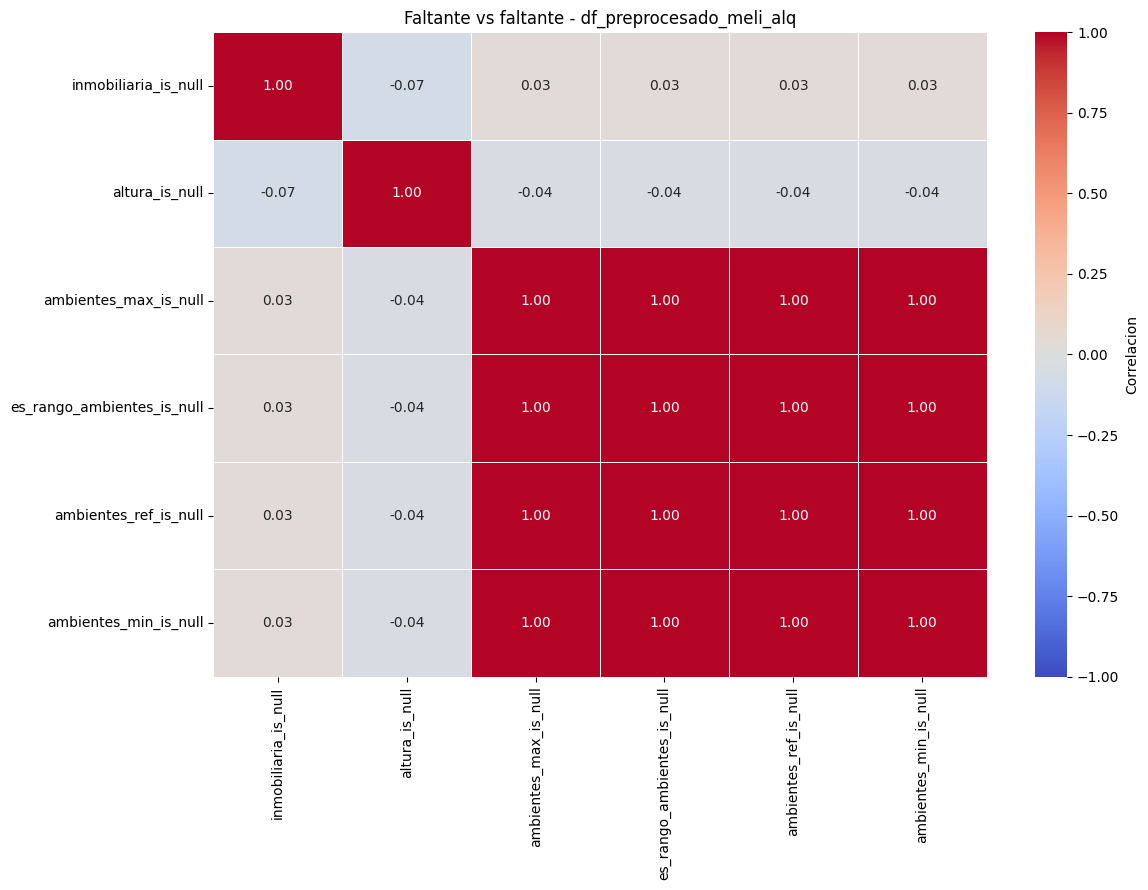

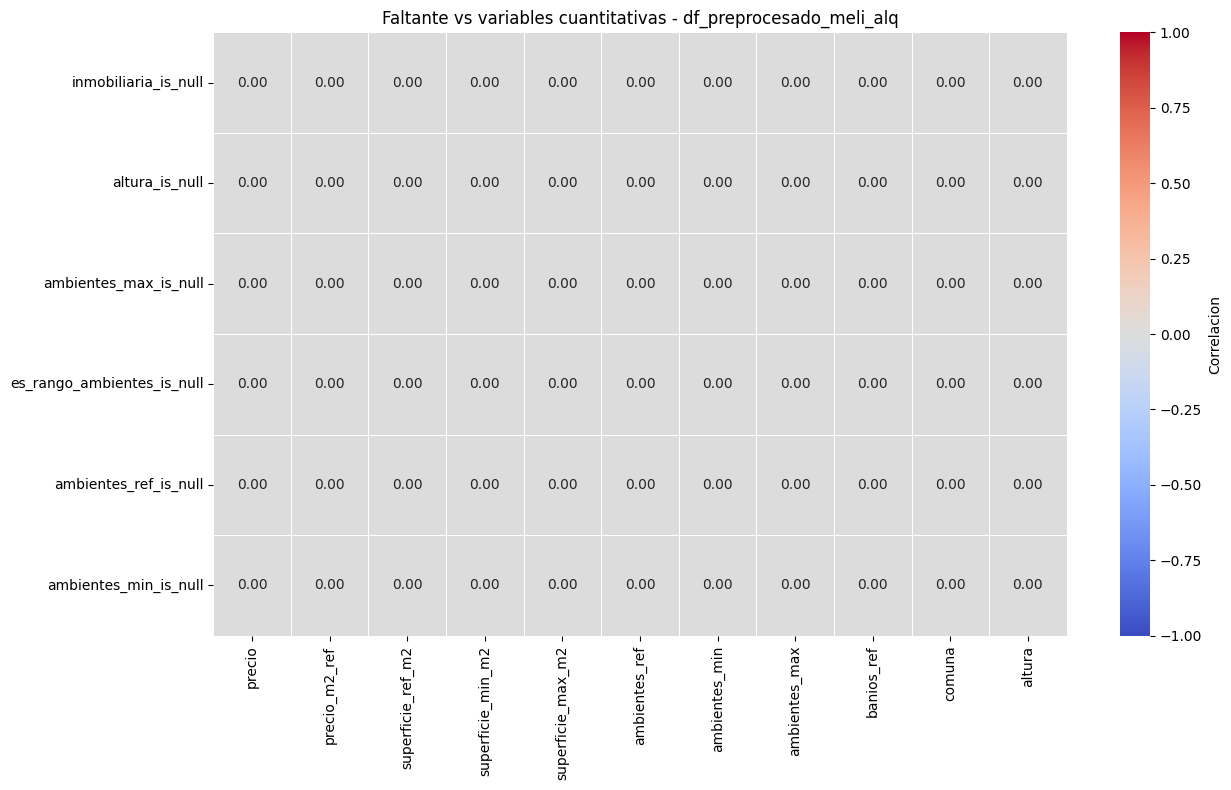


df_preprocesado_meli_alq_temp


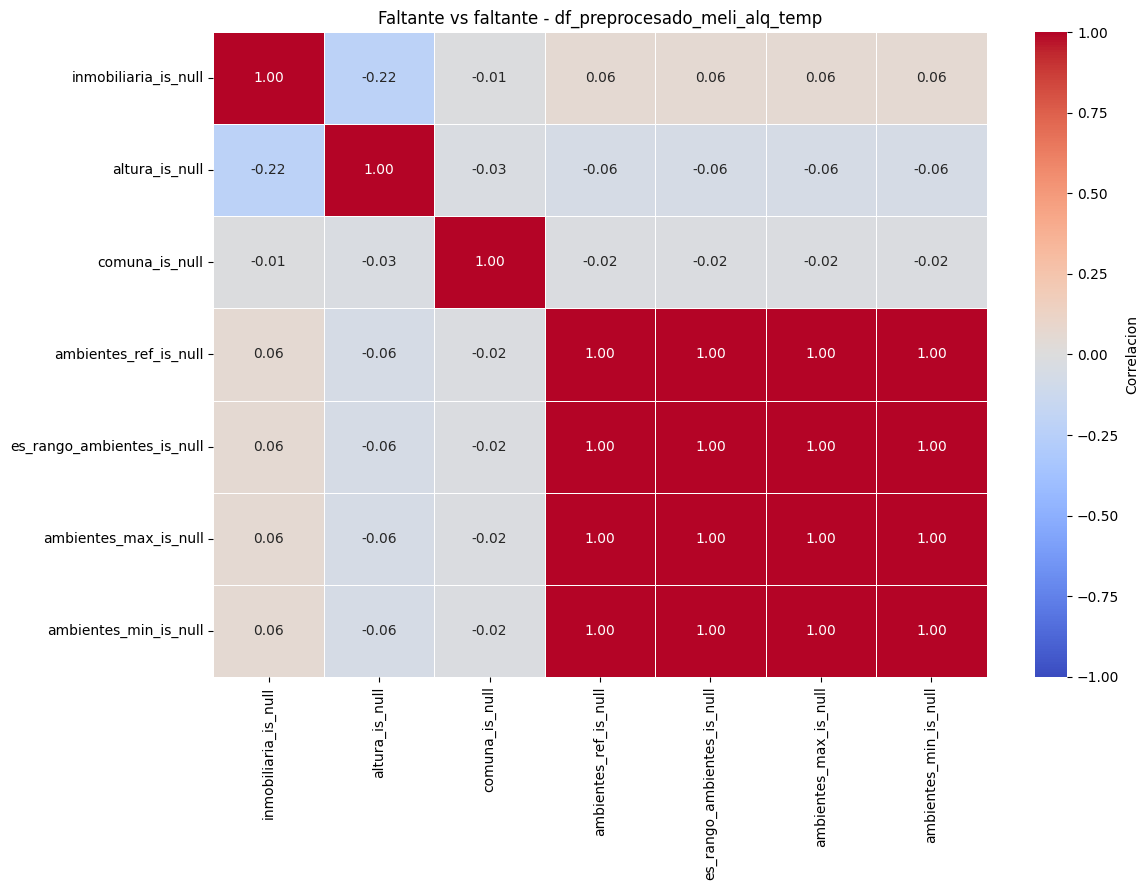

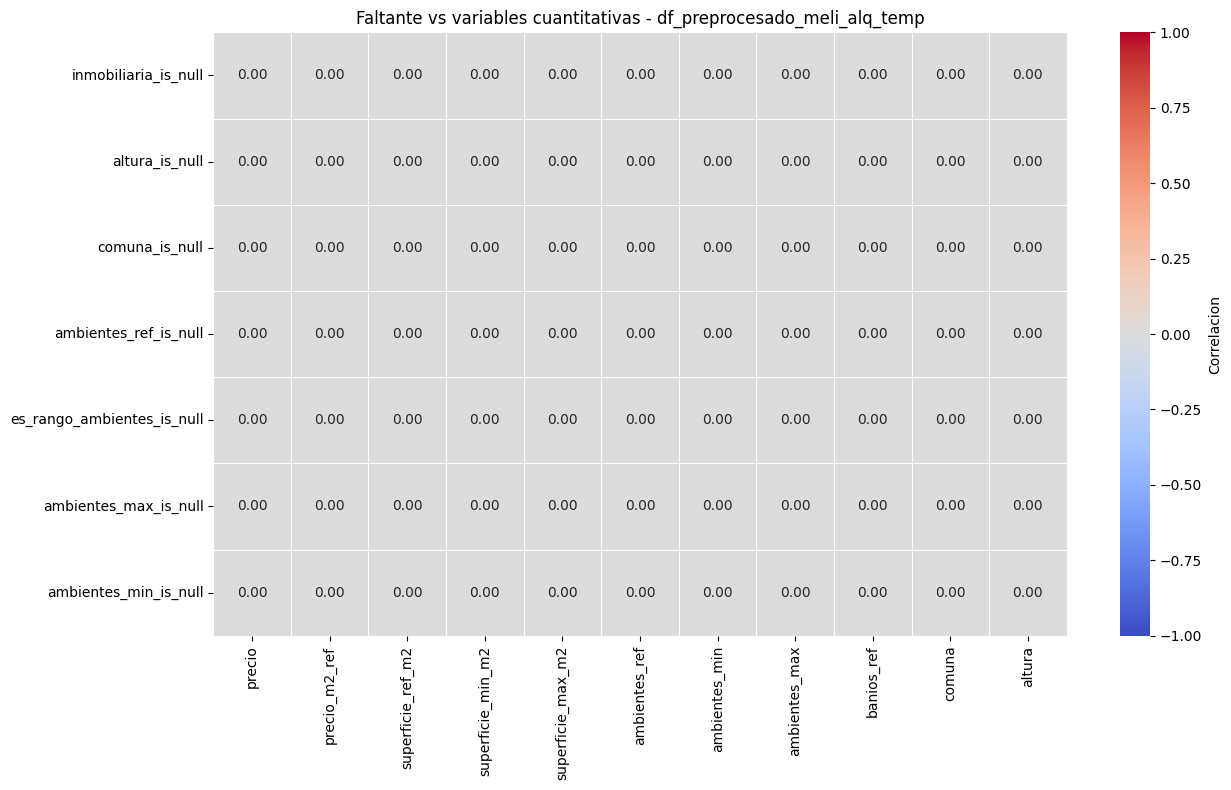


df_preprocesado_meli_vtas


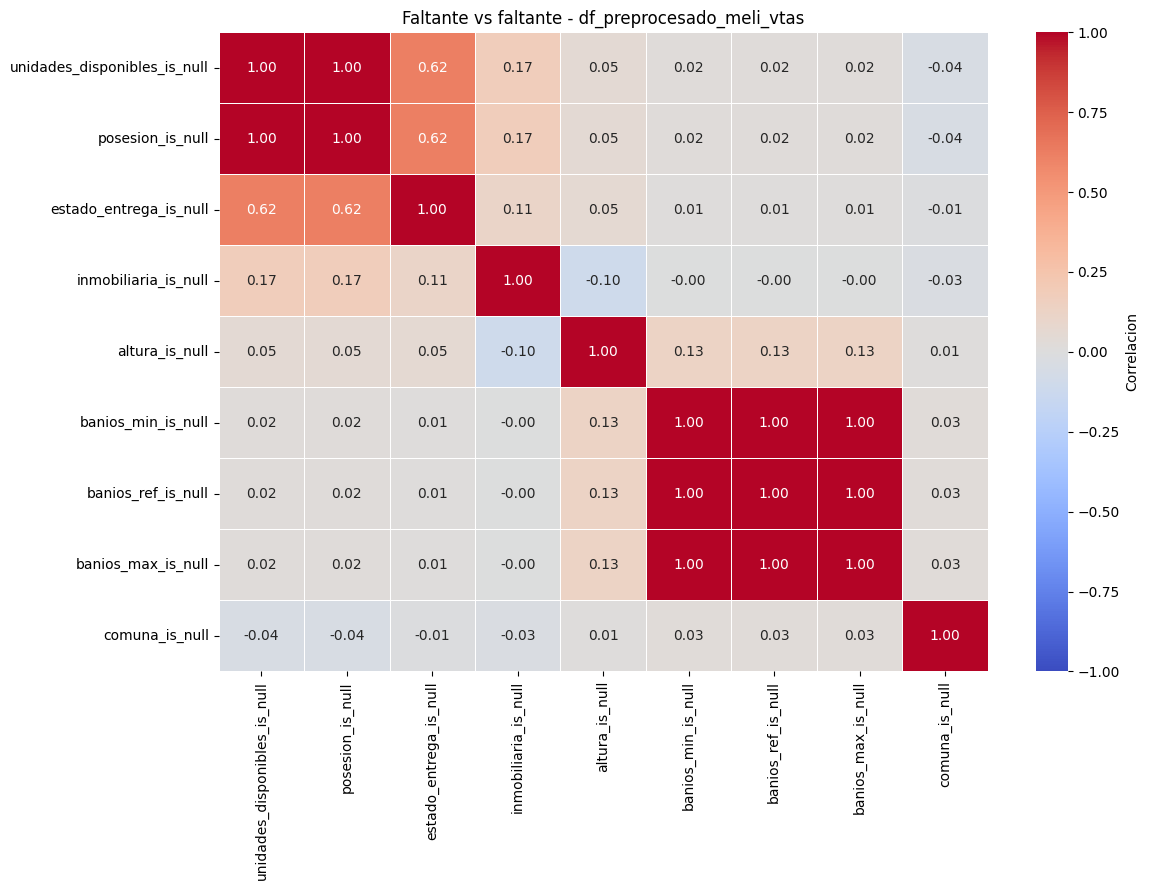

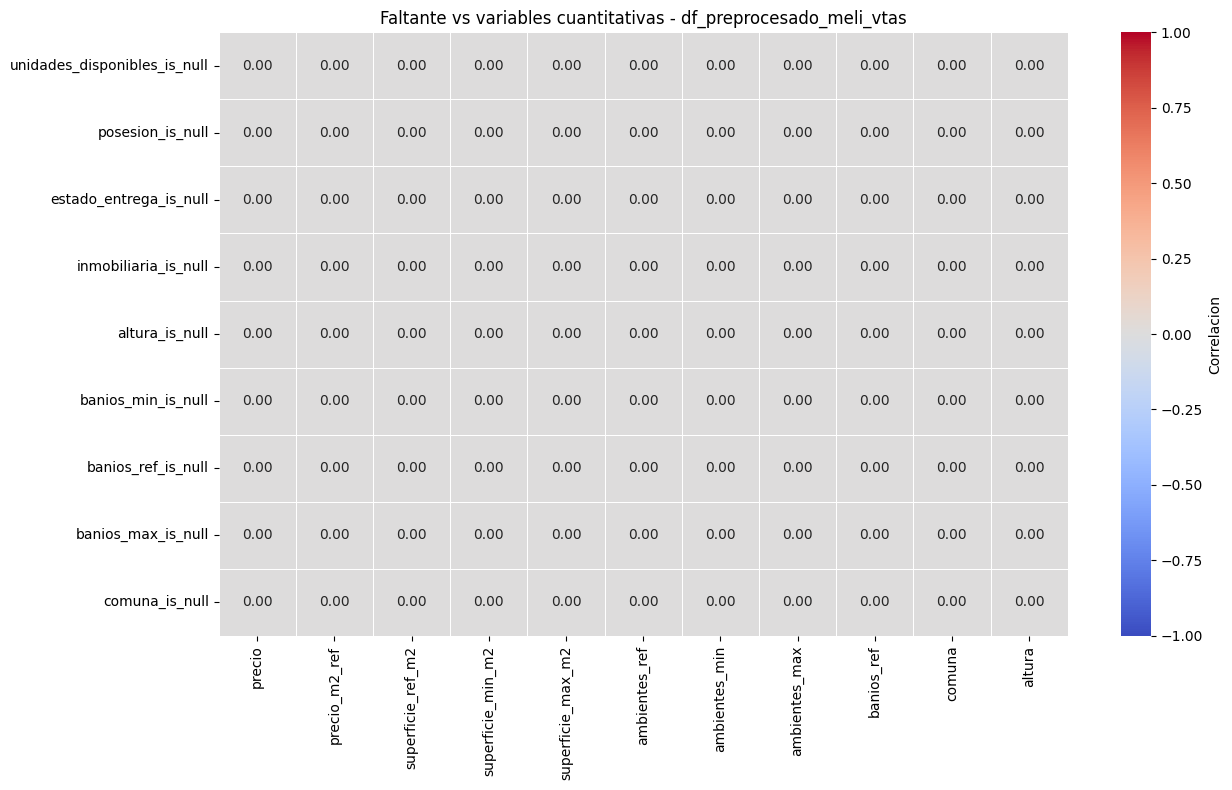


df_preprocesado_argenprop


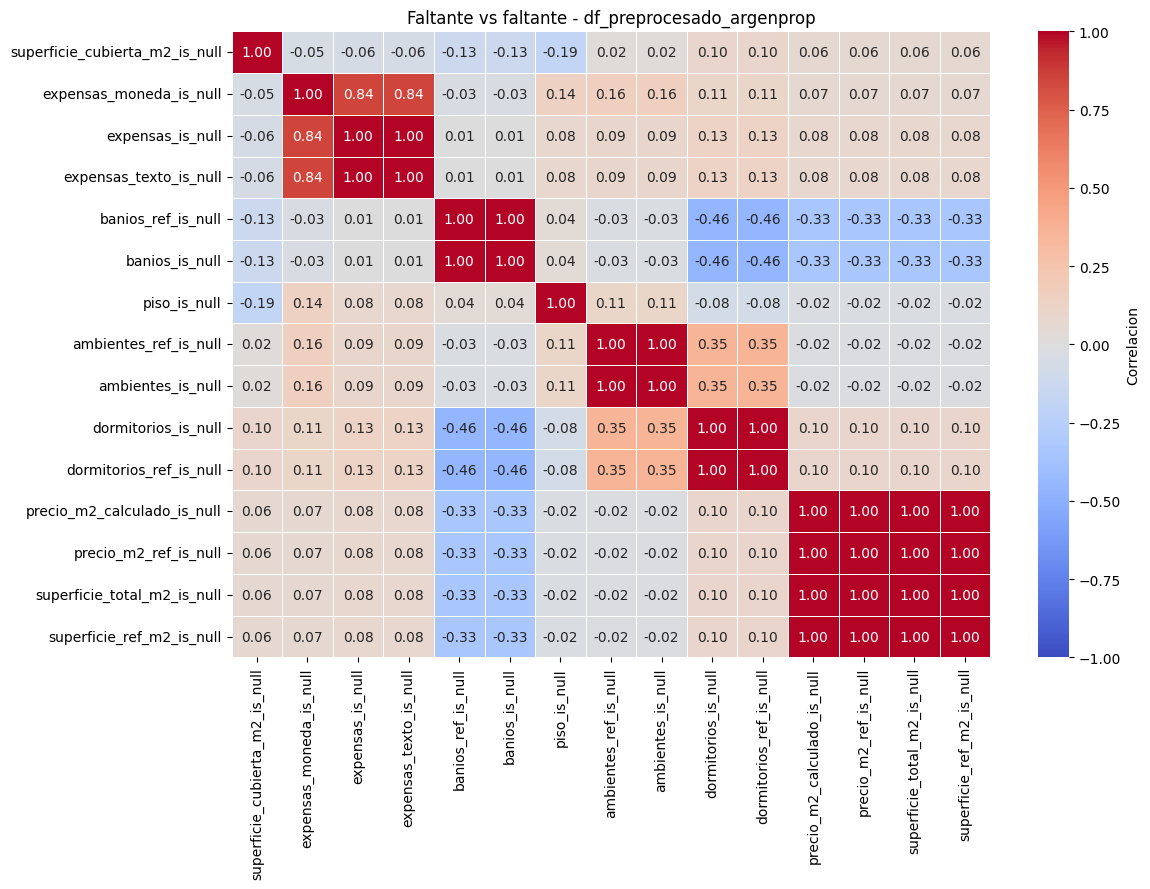

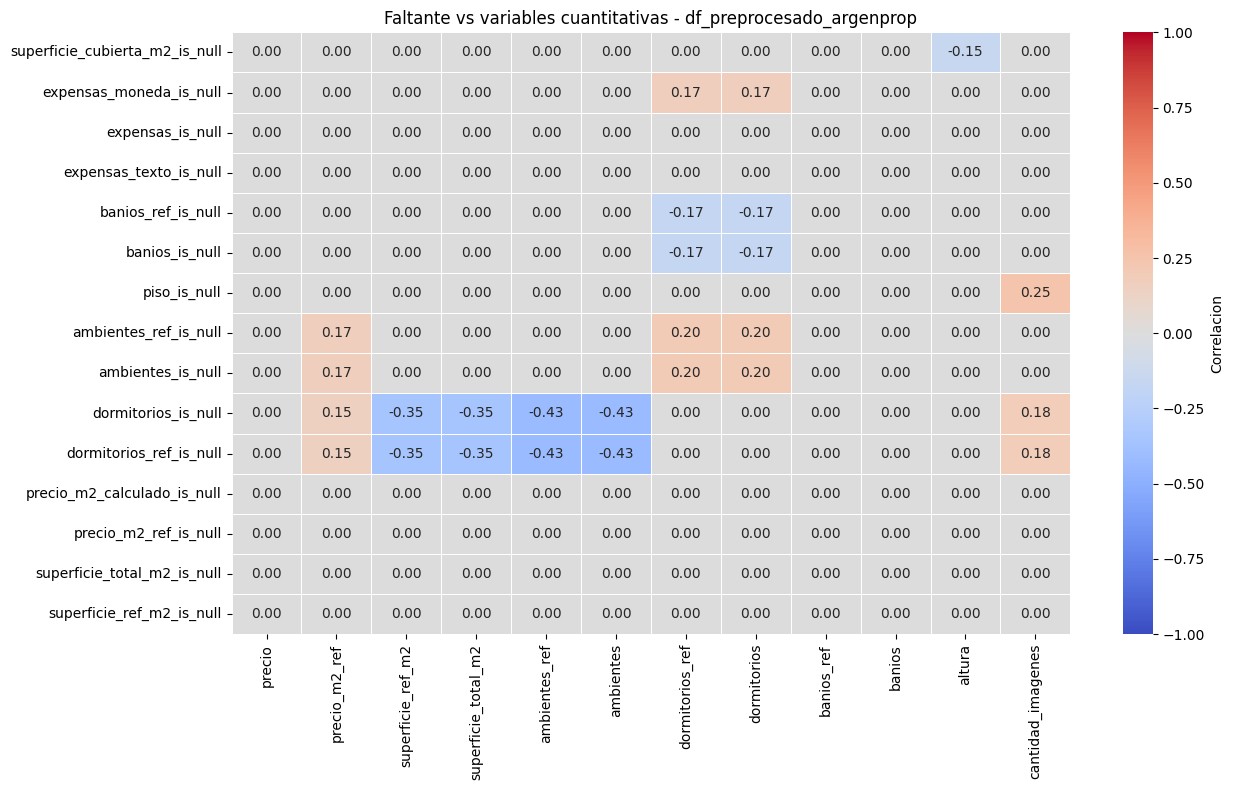


df_preprocesado_zonaprop


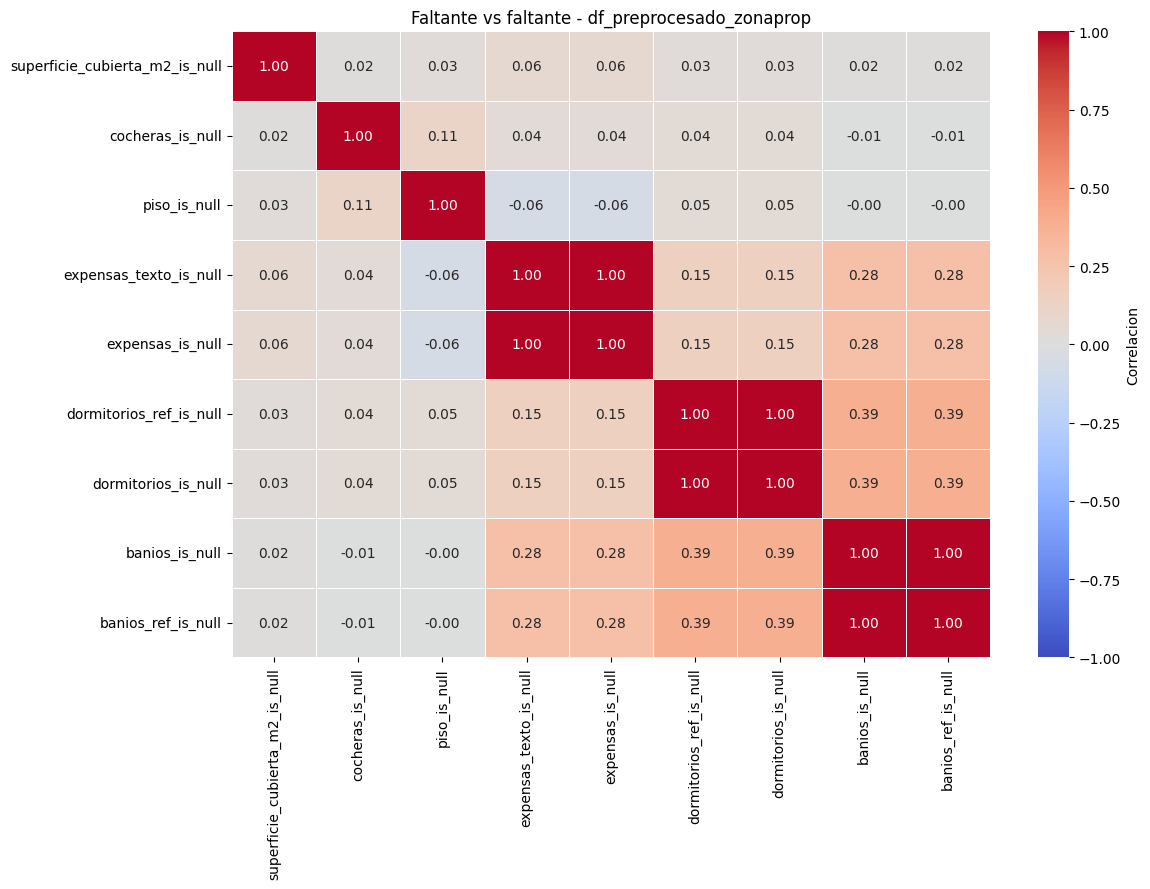

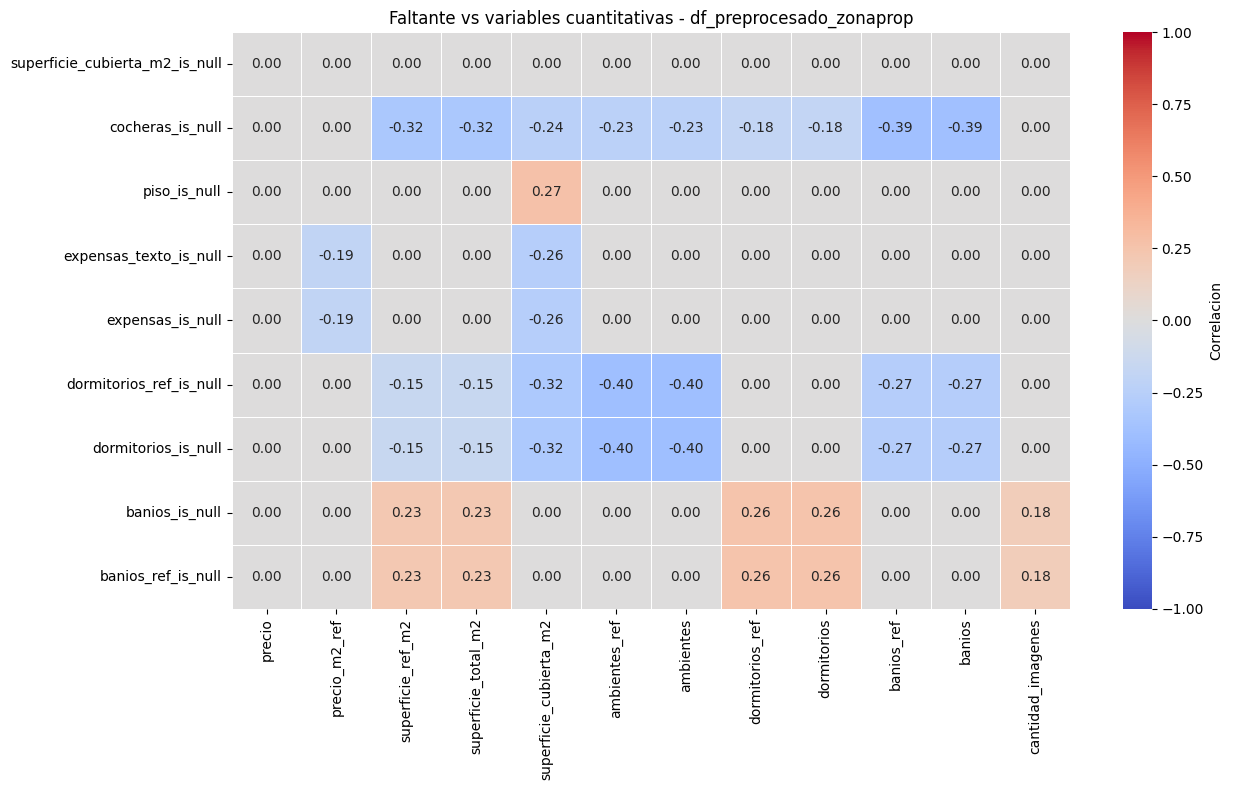


df_preprocesado_airbnb_temp


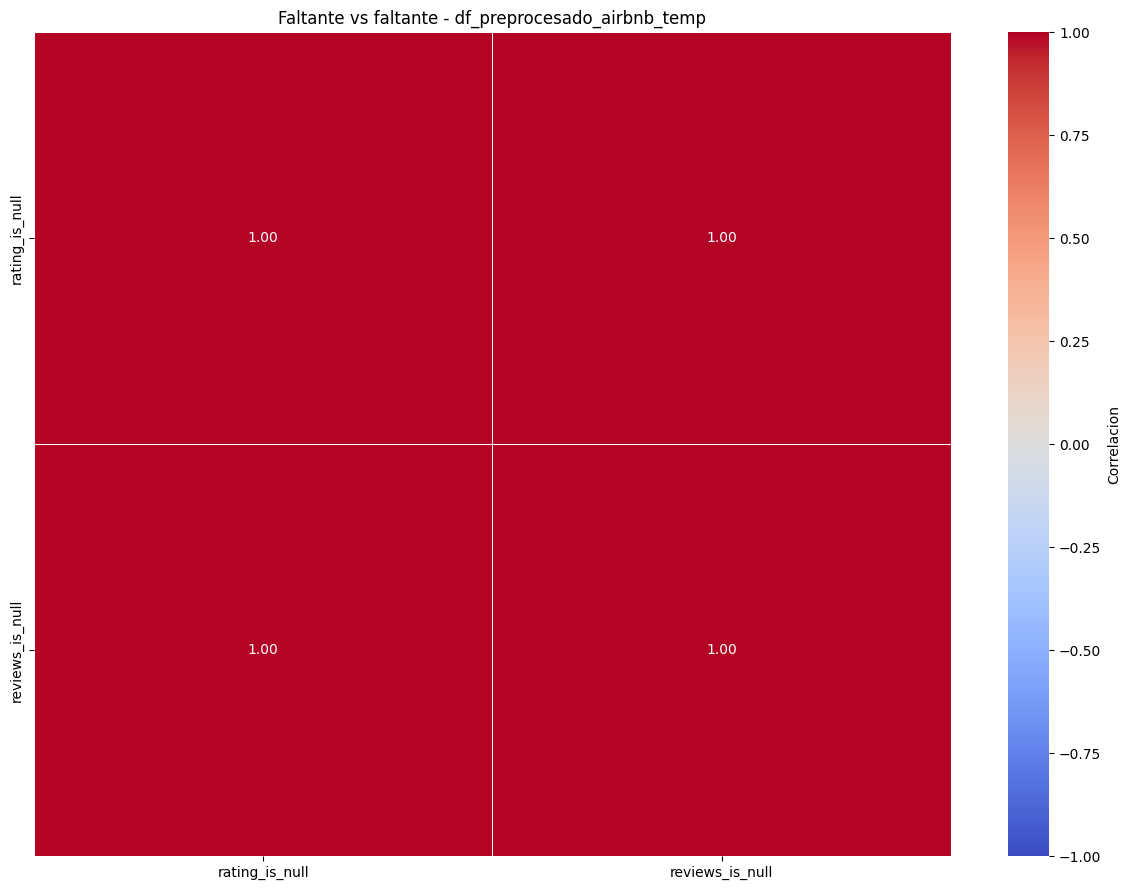

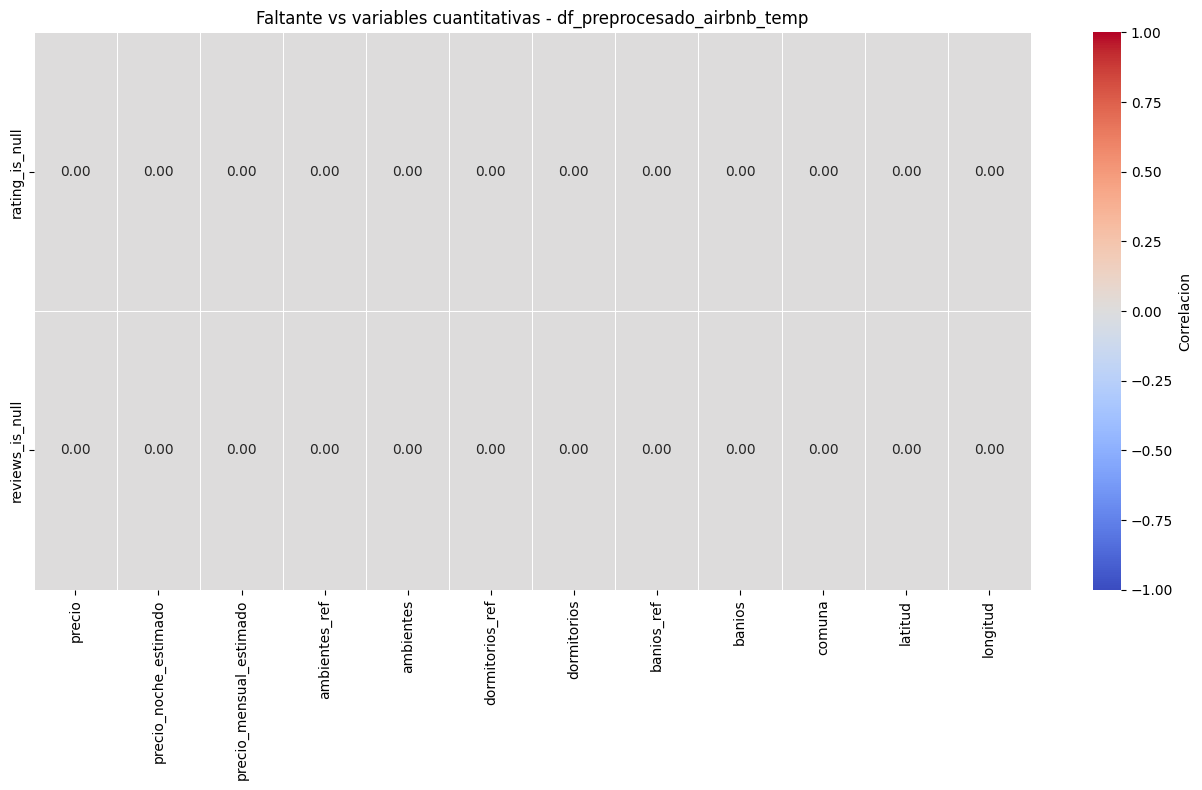

In [15]:
for name, df in preprocesados_con_flags.items():
    print('\n' + '=' * 100)
    print(name)

    flags = seleccionar_flags_informativos(df, min_pct=2, max_pct=98, max_flags=16)
    cuantitativas = seleccionar_cuantitativas_informativas(df, max_vars=12)

    if len(flags) < 2:
        print('No hay suficientes flags informativos de faltantes para este dataset.')
        continue

    matriz_faltante_faltante = df[flags].corr()
    matriz_faltante_faltante.to_csv(REPORTS_DIR / f'matriz_faltante_vs_faltante_{name}.csv')
    plot_heatmap_matriz(matriz_faltante_faltante, title=f'Faltante vs faltante - {name}', figsize=(12, 9), annot=True, mostrar_nan_como_cero=True)

    if len(cuantitativas) == 0:
        print('No hay variables cuantitativas informativas para cruzar contra faltantes.')
        continue

    matriz_faltante_cuantitativa = df[flags + cuantitativas].corr(numeric_only=True).loc[flags, cuantitativas]
    umbral_corr_cuantitativas = 0.15
    matriz_faltante_cuantitativa_filtrada = matriz_faltante_cuantitativa.where(matriz_faltante_cuantitativa.abs() >= umbral_corr_cuantitativas, other=0)
    matriz_faltante_cuantitativa.to_csv(REPORTS_DIR / f'matriz_faltante_vs_cuantitativas_{name}.csv')
    plot_heatmap_matriz(matriz_faltante_cuantitativa_filtrada, title=f'Faltante vs variables cuantitativas - {name}', figsize=(13, 8), annot=True, mostrar_nan_como_cero=True)

# Conclusiones de correlaciones

### MeLi alquiler

Se nota un cuadrado de correlaciones perfectas en variables de rangos de ambientes, min, y max.
Si recordamos que algunas publicaciones permite referir a varias propiedades (por ejemplo en la venta en bloque de dptos de edificios neuvos) permiten ingresar rangos, tiene sentido que estas variables aparezcan nulas de manera conjunta. Si no hay rango, no hay maximo ni minimo, y visceversa. Estas variables aparecen o quedan nulas en conjunto el 100% de las veces por como se expresa la informacion en la carga de datos. 

No se observan correlaciones entre faltantes y variables cuantitativas

### MeLi alquiler temporal

Mismo caso que antes en cuanto al cuadrado de correlaciones perfectas en rango de ambientes. Se observa una leve correlacion entre altura null e inmobiliaria null, que llama la antencion principalmente dado que no esta presente en el caso anterior. No hay correlaciones con variables cuantitativas

### MeLi ventas

Se observa un bloque en los rangos de banios. Tambie correlacion entre posesion y unidades disponibles. Posesion, que no habia sido documentada previamente, es una etiqueta que indica las condiciones de toma de posesion de los inmuebles (entrega immediata, pronta entrega, preventa, etc). Es esperable que se ausenten en conjunto ya que refieren a cuestiones de entrega/ disponibilidad de inmuebles

### Argenprop

Se observar correlaciones perfectas y fuertes en variables que van juntas, precio por metro y superficie, expensas y moneda de expensas, etc. Hay correlaciones no despreciables con variables cuantitativas, negativa entre nulidad de indicadores de dormitorios y cantidad de ambeintes y m2. A mayor tamanio de inmuebles (mas m2 y ambientes), menor ausencia indicadores de dormitorios. Esto puede referir al mayor detalle y desglose de publicaciones de mayor porte

### Zona Prop

Bloques en variables apareadas, correlacion notable entre detalles de las publicaciones, sin parejas que llamen la atencion. Variedad de correlaciones con variables cuantitativas, posibilidad de analisis de impacto del faltante. 

### Airbnb

Cuadrado de reviews/ resenias, falta de correlacion con cuantitativas. 

# Resumen

No hay correlaciones entre nulos que llamen la atencion, la mayoria de emparejan perfectamente al referir a conceptos relacionados (puntas de rango, atributos de un mismo subdominio). 

Respecto de la relacion con variables cuantitativas, hay indicios con correlaciones sospechosamente altas. No se descarta un impacto sobre los analisis. 

## Faltantes por label de variables categóricas, discriminado por dataset

Este análisis evita que el consolidado quede dominado por diferencias de estructura entre fuentes. Para cada dataset se cruzan flags de faltantes contra labels de variables categóricas existentes en ese mismo dataset.


df_preprocesado_meli_alq


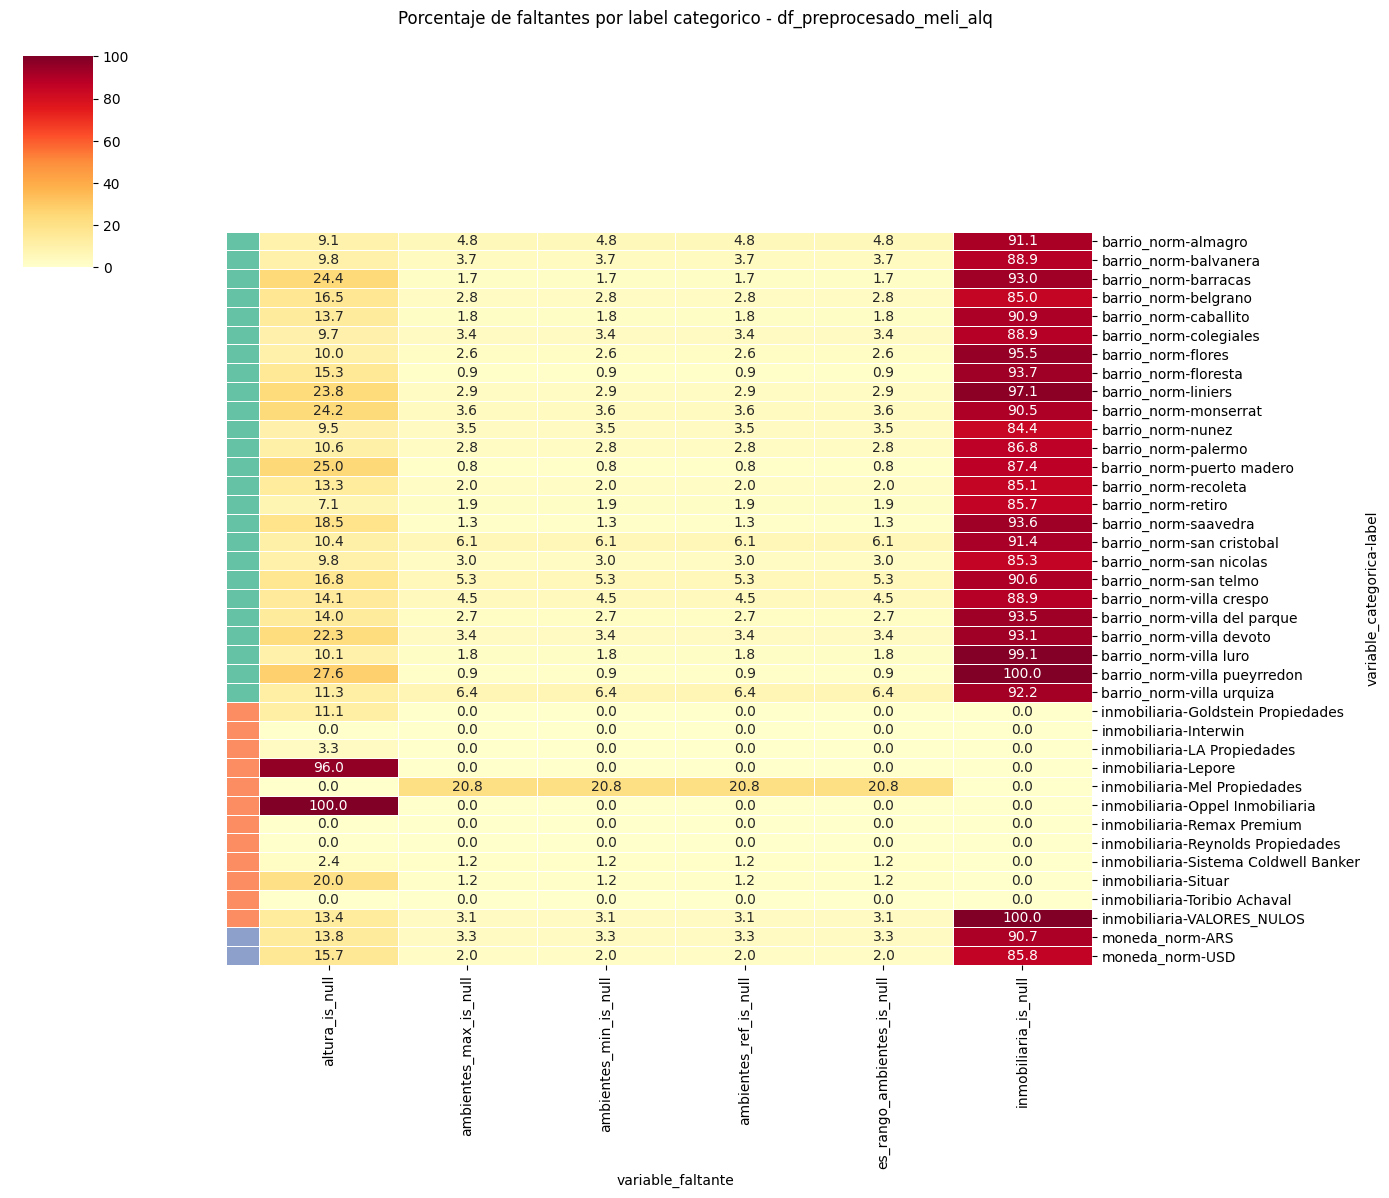


df_preprocesado_meli_alq_temp


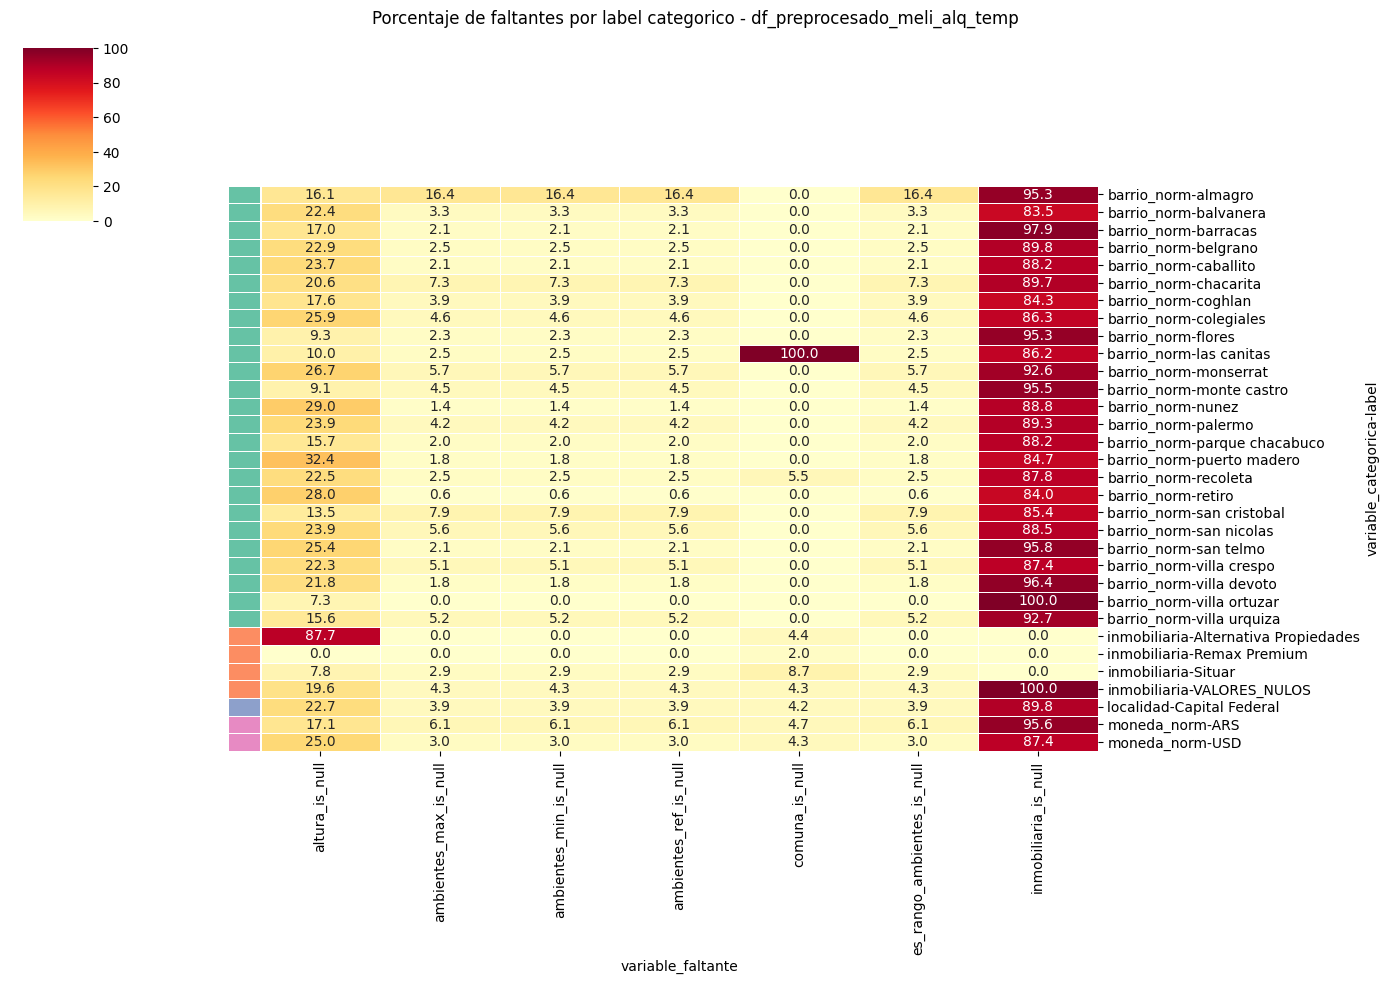


df_preprocesado_meli_vtas


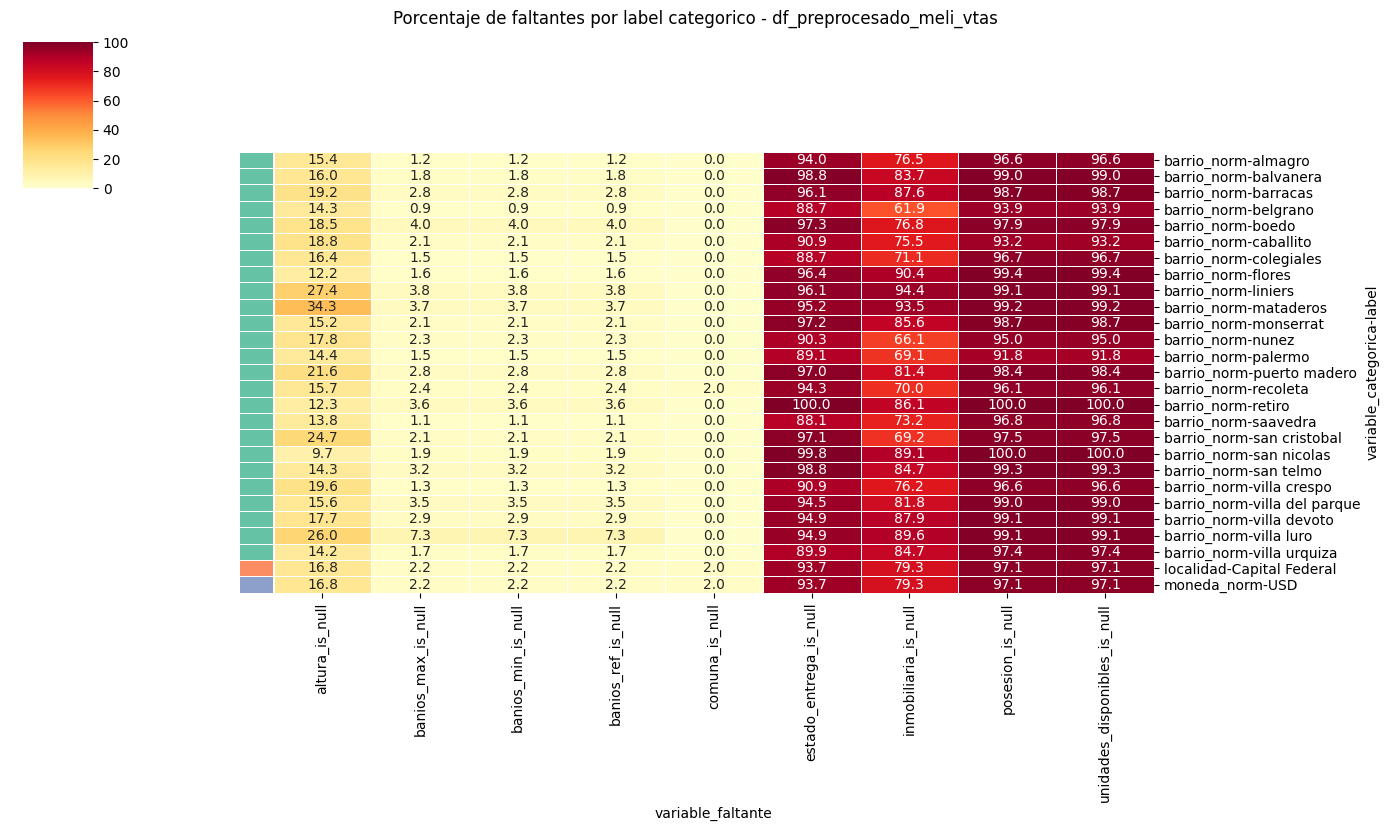


df_preprocesado_argenprop


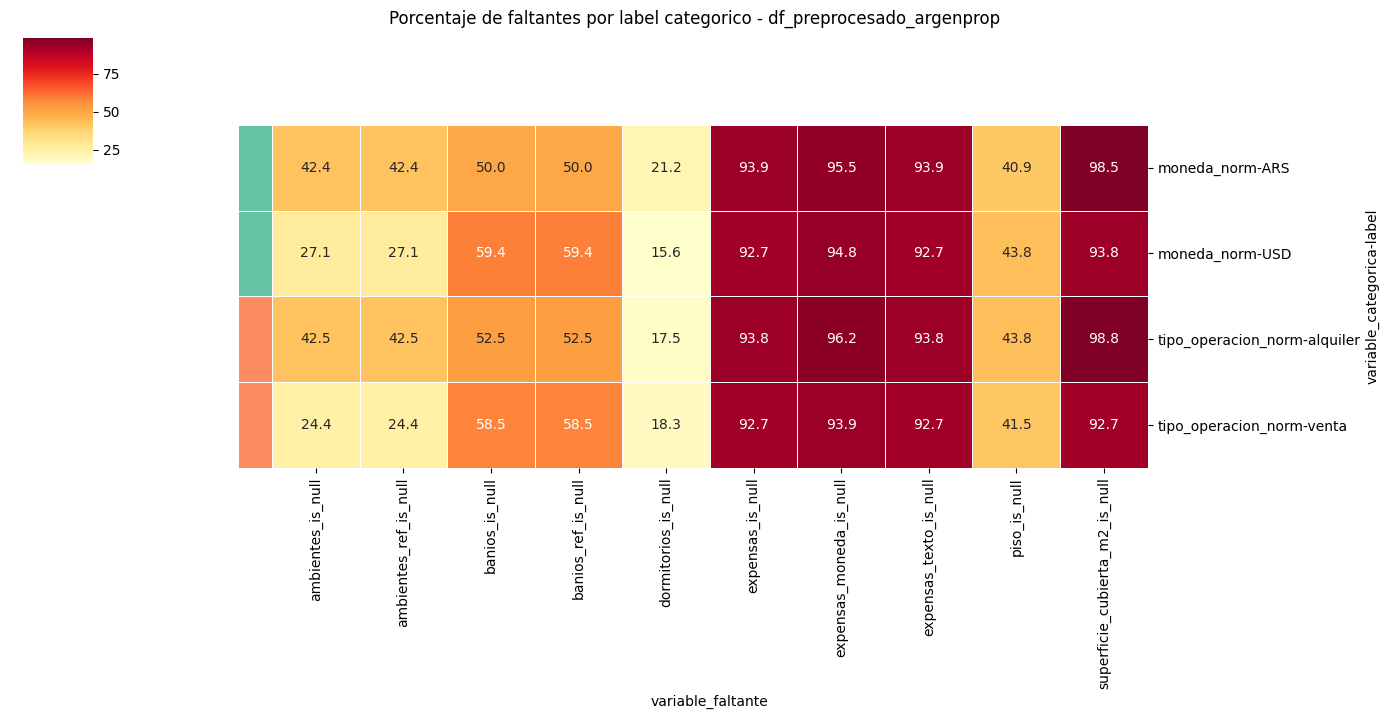


df_preprocesado_zonaprop


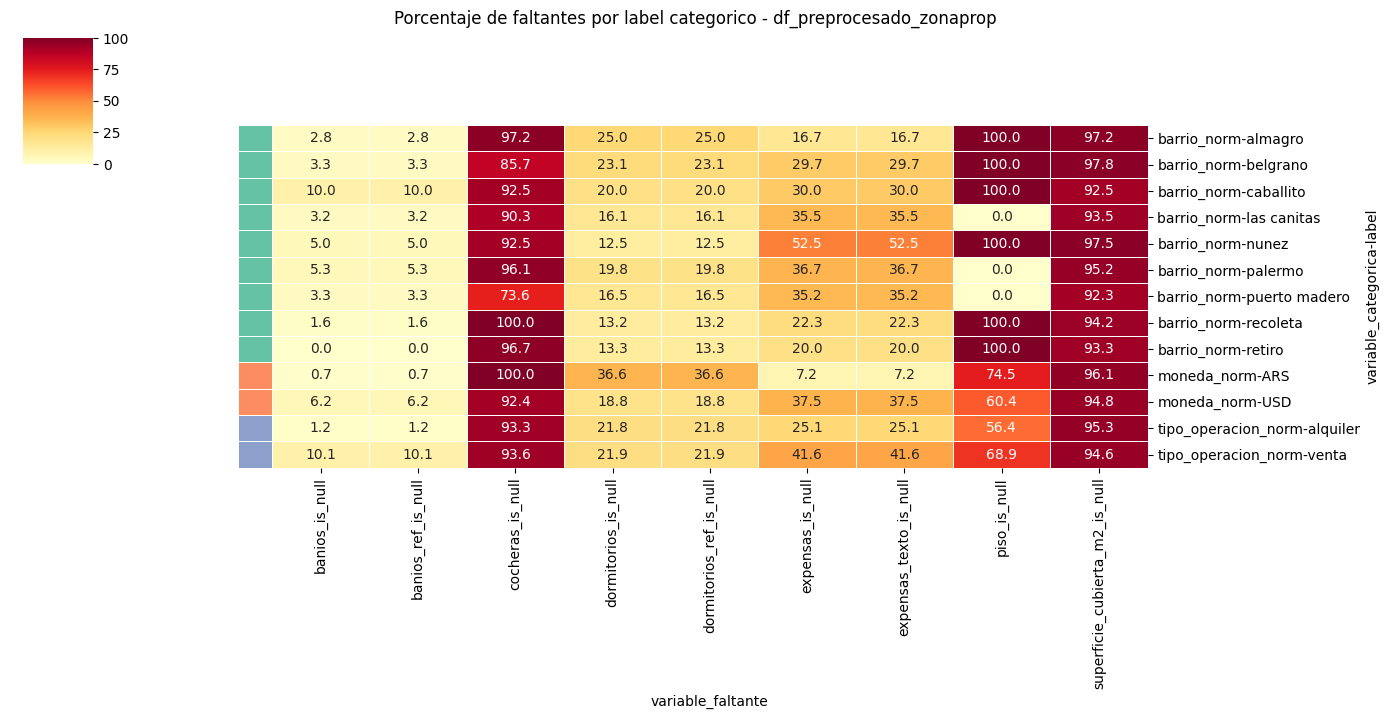


df_preprocesado_airbnb_temp


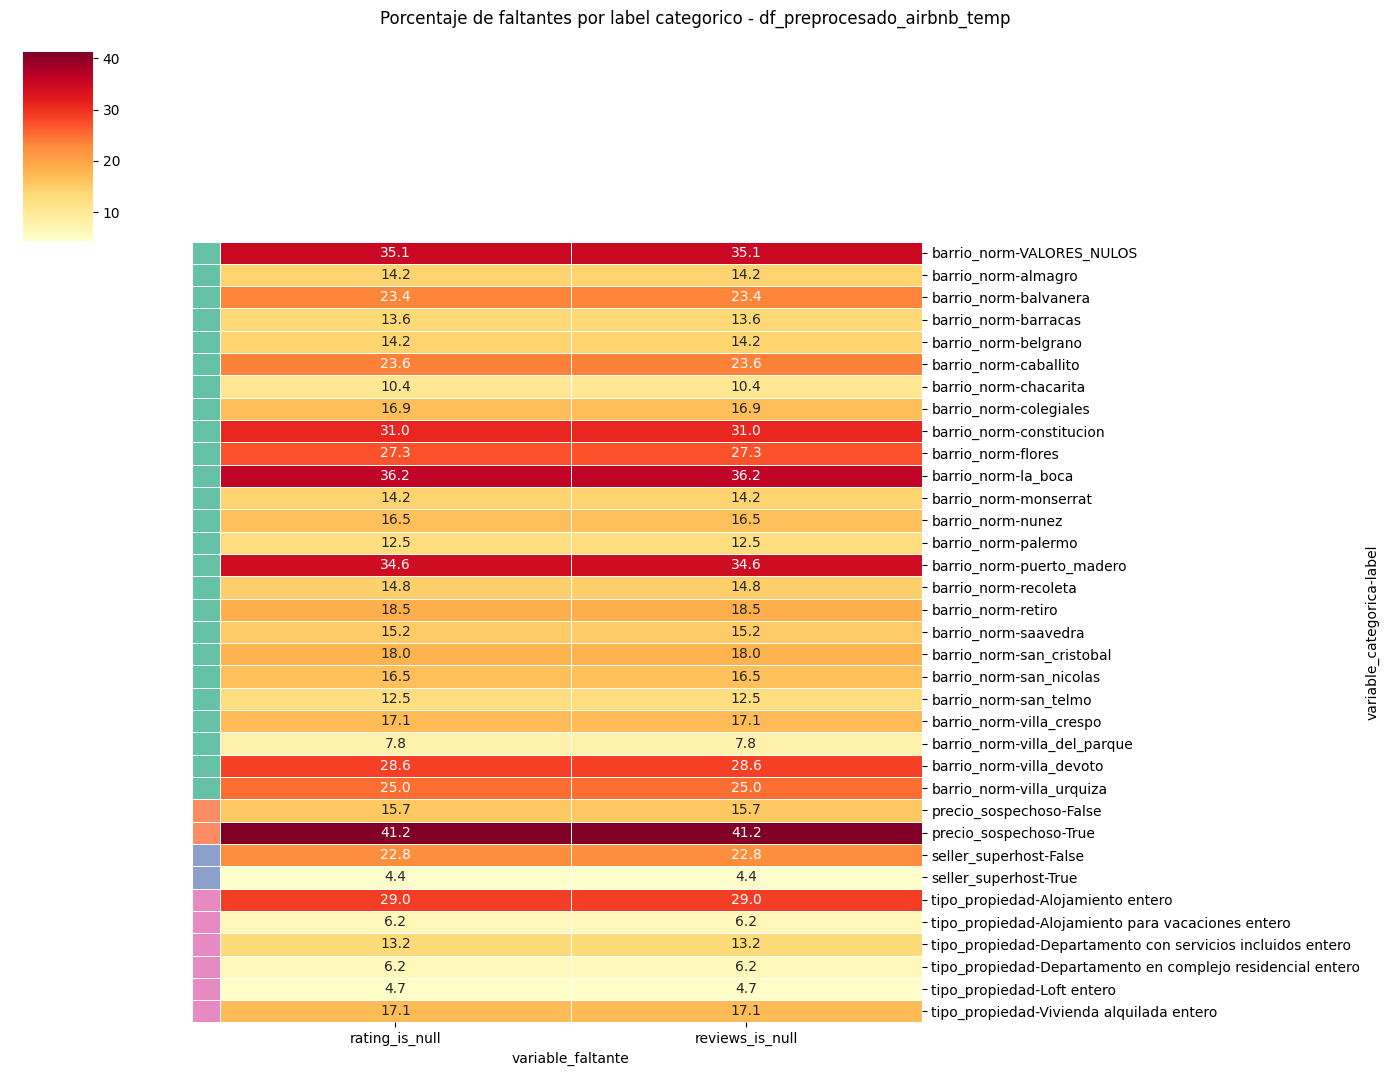

,dataset,variable_categorica,label,n_registros,variable_faltante,pct_faltante
0,df_preprocesado_meli_alq,moneda_norm,ARS,8232,inmobiliaria_is_null,90.67
1,df_preprocesado_meli_alq,moneda_norm,ARS,8232,altura_is_null,13.79
2,df_preprocesado_meli_alq,moneda_norm,ARS,8232,ambientes_max_is_null,3.34
3,df_preprocesado_meli_alq,moneda_norm,ARS,8232,es_rango_ambientes_is_null,3.34
4,df_preprocesado_meli_alq,moneda_norm,ARS,8232,ambientes_ref_is_null,3.34
5,df_preprocesado_meli_alq,moneda_norm,ARS,8232,ambientes_min_is_null,3.34
6,df_preprocesado_meli_alq,moneda_norm,USD,3247,inmobiliaria_is_null,85.83
7,df_preprocesado_meli_alq,moneda_norm,USD,3247,altura_is_null,15.65
8,df_preprocesado_meli_alq,moneda_norm,USD,3247,ambientes_max_is_null,1.97
9,df_preprocesado_meli_alq,moneda_norm,USD,3247,es_rango_ambientes_is_null,1.97


In [16]:
resumenes_faltantes_por_label = []
for name, df in preprocesados_con_flags.items():
    print('\n' + '=' * 100)
    print(name)

    flags_diagnostico = seleccionar_flags_problematicos(df, min_pct=2, max_pct=98, top_n=10)
    cat_cols_diagnostico = seleccionar_categoricas_informativas(df, max_cols=6)

    if not flags_diagnostico:
        print('No hay flags de faltantes informativos para este dataset.')
        continue
    if not cat_cols_diagnostico:
        print('No hay variables categoricas informativas para este dataset.')
        continue

    df_faltantes_label_dataset = faltantes_por_labels_categoricos(df, cat_cols_diagnostico, flags_diagnostico, dataset_name=name, min_count=30, top_labels_por_col=25)
    if df_faltantes_label_dataset.empty:
        print('No hay combinaciones con volumen suficiente para graficar.')
        continue

    resumenes_faltantes_por_label.append(df_faltantes_label_dataset)
    df_faltantes_label_dataset.to_csv(REPORTS_DIR / f'faltantes_por_label_categorico_{name}.csv', index=False)
    graficar_faltantes_por_label(df_faltantes_label_dataset, dataset_name=name)

if resumenes_faltantes_por_label:
    df_faltantes_por_label_todos = pd.concat(resumenes_faltantes_por_label, ignore_index=True)
    df_faltantes_por_label_todos.to_csv(REPORTS_DIR / 'faltantes_por_label_categorico_todos_los_datasets.csv', index=False)
    display(df_faltantes_por_label_todos.head(50))

# Conclusiones de correlaciones

### MeLi alquiler

Los nulos se distribuyen con relativa uniformidad por los barrios. Mismo con las inmobiliarias, salvo una que tiende a excluir los rangos en bloque, y otras dos que suelen excluir las alturas. Inmobiliaria casi siempre nula, considerar usabilidad. Vairable de localidad con 1 sola label, no es util. 

### MeLi alquiler temporal

Relativa uniformidad, comuna faltante en 100% de las canitas. Esto es porque las canitas no es un barrio oficial, y debe ser reemplazdo por Palermo.

### MeLi ventas

Las variables relativas a la disponibilidad de la entrega tienen muchos nulos, reconsiderar usabiliad. 

### Argenprop y Zonaprop

Diferencias notables entre los tipos de operacion, se requiere mas procesamiento al estar tratando con dos elementos distintos.

### Airbnb

Variables de ratings no distribuidas uniformemente entre labels, a considerar si se utiliza la columna. 

# Resumen

No hay inconvenientes que no sean facilmente explicables, al menos para las variables de mayos uso. Se hacen algunas transformaciones. 

In [20]:
df_preprocesado_meli_alq_temp['barrio'] = df_preprocesado_meli_alq_temp['barrio'].astype(str).replace(
    {'las canita': 'palermo'})
df_preprocesado_zonaprop['barrio'] = df_preprocesado_zonaprop['barrio'].astype(str).replace(
    {'las canita': 'palermo'})


# Separar DFs de ZonaProp y ArgenProp

A este punto, emerge la necesidad de separar los dfs de estos portales. Ambas base se originan del mismo scrapper, por lo que comparten estructura. Sin embargo, cada una incluye ventas y alquileres, y en esta etapa resulta conveniente tratarlos por separado ya que los nulos no se distribuyen uniformemente por categoria. Luego, pueden reconbinarse para analisis posterior


In [18]:
# HACER LAS TRANSFORMACIONES

# Argenprop y Zonaprop llegan a esta altura como un unico dataset que mezcla
# venta y alquiler (distinguidos por 'tipo_operacion_norm'), a diferencia de
# Meli, que ya viene separado en archivos por operacion. Se separan aca para
# que todas las fuentes queden con la misma granularidad (un dataset por
# fuente x operacion) de cara a las etapas siguientes.

def separar_por_operacion(nombre_base, df, mapeo_operaciones):
    """Divide un DataFrame por 'tipo_operacion_norm' segun el mapeo dado
    (ej. {'venta': 'vtas', 'alquiler': 'alq'}) y devuelve un dict
    {f'{nombre_base}_{sufijo}': sub_df}. Avisa si aparece alguna categoria
    de operacion no contemplada en el mapeo, para no perder filas en
    silencio."""
    resultado = {}
    categorias_presentes = set(df['tipo_operacion_norm'].dropna().unique())
    categorias_sin_mapear = categorias_presentes - set(mapeo_operaciones)
    if categorias_sin_mapear:
        print(f'AVISO [{nombre_base}]: categorias sin mapear, se excluyen: {categorias_sin_mapear}')

    for valor_operacion, sufijo in mapeo_operaciones.items():
        sub_df = df[df['tipo_operacion_norm'] == valor_operacion].copy()
        clave = f'{nombre_base}_{sufijo}'
        resultado[clave] = sub_df
        print(clave, sub_df.shape)
    return resultado


MAPEO_OPERACIONES_PORTALES = {'venta': 'vtas', 'alquiler': 'alq'}

argenprop_split = separar_por_operacion(
    'df_preprocesado_argenprop',
    preprocesados_con_flags.pop('df_preprocesado_argenprop'),
    MAPEO_OPERACIONES_PORTALES,
)
zonaprop_split = separar_por_operacion(
    'df_preprocesado_zonaprop',
    preprocesados_con_flags.pop('df_preprocesado_zonaprop'),
    MAPEO_OPERACIONES_PORTALES,
)

# Se reemplazan las entradas combinadas por las divididas, y se registran
# como variables sueltas (mismo patron que las celdas anteriores del
# notebook), para poder referenciarlas por nombre mas adelante si hiciera falta.
preprocesados_con_flags.update(argenprop_split)
preprocesados_con_flags.update(zonaprop_split)
for nombre, df in {**argenprop_split, **zonaprop_split}.items():
    globals()[nombre] = df

print('\nDatasets luego de la separacion:')
for nombre in preprocesados_con_flags:
    print(' -', nombre)

df_preprocesado_argenprop_vtas (82, 186)
df_preprocesado_argenprop_alq (80, 186)
df_preprocesado_zonaprop_vtas (485, 189)
df_preprocesado_zonaprop_alq (495, 189)

Datasets luego de la separacion:
 - df_preprocesado_meli_alq
 - df_preprocesado_meli_alq_temp
 - df_preprocesado_meli_vtas
 - df_preprocesado_airbnb_temp
 - df_preprocesado_argenprop_vtas
 - df_preprocesado_argenprop_alq
 - df_preprocesado_zonaprop_vtas
 - df_preprocesado_zonaprop_alq


## Guardado de versiones con flags de nulos

In [19]:
for name, df in preprocesados_con_flags.items():
    path = PROCESSED_DIR / f'{name}_con_flags_nulos_v1.csv'
    df.to_csv(path, index=False)
    print('Guardado:', path.relative_to(REPO_ROOT), df.shape)

canonical_frames = []
for name, df in preprocesados_con_flags.items():
    cols = [c for c in df.columns if c in [
        'id_publicacion', 'fuente_norm', 'fuente', 'tipo_operacion_norm', 'tipo_operacion', 'url', 'fecha_extraccion',
        'scraped_at_utc', '_archivo_origen', 'titulo', 'descripcion', 'tipo_propiedad', 'moneda_norm', 'moneda',
        'precio', 'precio_texto', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'barrio',
        'barrio_norm', 'comuna', 'localidad', 'provincia', 'pais', 'direccion', 'direccion_completa', 'calle',
        'altura', 'latitud', 'longitud', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref'
    ] or c.endswith('_is_null')]
    tmp = df[cols].copy()
    tmp['dataset_preprocesado'] = name
    canonical_frames.append(tmp)

df_publicaciones_consolidadas_nulos = pd.concat(canonical_frames, ignore_index=True, sort=False)
df_publicaciones_consolidadas_nulos.to_csv(PROCESSED_DIR / 'df_publicaciones_consolidadas_con_flags_nulos_v1.csv', index=False)
print(df_publicaciones_consolidadas_nulos.shape)

Guardado: data\processed\df_preprocesado_meli_alq_con_flags_nulos_v1.csv (11479, 103)
Guardado: data\processed\df_preprocesado_meli_alq_temp_con_flags_nulos_v1.csv (6190, 104)
Guardado: data\processed\df_preprocesado_meli_vtas_con_flags_nulos_v1.csv (44013, 105)
Guardado: data\processed\df_preprocesado_airbnb_temp_con_flags_nulos_v1.csv (9596, 90)
Guardado: data\processed\df_preprocesado_argenprop_vtas_con_flags_nulos_v1.csv (82, 186)
Guardado: data\processed\df_preprocesado_argenprop_alq_con_flags_nulos_v1.csv (80, 186)
Guardado: data\processed\df_preprocesado_zonaprop_vtas_con_flags_nulos_v1.csv (485, 189)
Guardado: data\processed\df_preprocesado_zonaprop_alq_con_flags_nulos_v1.csv (495, 189)
(72420, 147)


## Cierre del análisis de nulos

Los faltantes se analizan por dataset para evitar conclusiones falsas producidas por columnas que existen en una fuente pero no en otra. Los flags generados quedan disponibles para outliers, EDA y análisis posteriores.

# Tratameinto